# Pipeline de Análisis de Datos — Sub-pregunta Q3
### Biomaterial Scaffold Design for Tissue Engineering: A Data-Driven Systematic Review

Este notebook reconstruye, paso a paso, el pipeline descrito en la Sección 4.1 del paper:
1. Segmentación de texto en fragmentos
2. Generación de embeddings con BioBERT
3. Modelado de tópicos (UMAP + HDBSCAN vía BERTopic)
4. Limpieza manual de tópicos (ruido bibliográfico/licencias)
5. Agrupación en K grupos temáticos (K-means + método del codo + silueta)
6. Extracción de entidades biomédicas (NER)
7. Construcción de redes de co-ocurrencia
8. Métricas de centralidad y visualización

**Nota importante de reproducibilidad:** el pipeline original no fijó una semilla aleatoria
(`random_state`) ni registró versiones exactas de librerías — esto se reconoce como limitación
en el paper (Sección 4.1). Este notebook fija semillas por defecto para que future corridas
sean reproducibles entre sí, pero los resultados exactos (K óptimo, asignación de tópicos)
pueden diferir ligeramente de los reportados originalmente, especialmente dado el bajo valor
de silueta (0.09) que indica separación débil entre clusters.

**Qué necesitas antes de correr esto:** una carpeta con el texto completo (full text) de tus
78 (o 87) estudios, un archivo de texto por estudio, nombrado con su ID (ej. `P02.txt`, `W03.txt`).
Sube esa carpeta a Colab o móntala desde Google Drive antes de correr la Fase 1.

## Fase 0 — Instalación de librerías

In [ ]:
!pip install -q sentence-transformers bertopic umap-learn hdbscan scikit-learn
!pip install -q transformers networkx matplotlib pandas numpy


In [ ]:
!pip install "pillow>=12.2.0" --force-reinstall -q


In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd

# ===== Semillas fijas para reproducibilidad =====
SEED = 33
random.seed(SEED)
np.random.seed(SEED)

print("Librerias listas. Semilla fija en:", SEED)


Librerias listas. Semilla fija en: 33


## Fase 0.5 --- Convertir tus ZIPs de PDFs a texto (.txt)

Sube tus archivos `.zip` (pueden ser varios, ej. 4 partes) a Colab (icono de carpeta a
la izquierda > Subir), corre la celda de diagnostico de abajo para ver sus nombres
exactos, y edita la lista `RUTAS_ZIP` en la siguiente celda con esos nombres. Esta celda
descomprime TODOS los zips en una misma carpeta, extrae el texto de cada PDF encontrado
(sin importar en cual zip estaba), y guarda un `.txt` por cada uno en
`/content/textos_completos/` -- usando el mismo nombre que ya tenia cada PDF.

In [ ]:
!pip install -q pdfplumber ftfy

In [ ]:
import os
import re
import zipfile
import pdfplumber
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIGURACIÓN
# ============================================================

RUTAS_ZIP = [
    Path("/content/PDFs_78_papers_parte1.zip"),
    Path("/content/PDFs_78_papers_parte2.zip"),
    Path("/content/PDFs_78_papers_parte3.zip"),
    Path("/content/PDFs_78_papers_parte4.zip"),
]

CARPETA_PDFS = Path("/content/pdfs_extraidos")
CARPETA_TEXTOS_BRUTOS = Path("/content/textos_brutos")

CARPETA_PDFS.mkdir(parents=True, exist_ok=True)
CARPETA_TEXTOS_BRUTOS.mkdir(parents=True, exist_ok=True)

MARCADOR_PAGINA = "\n\n[[[PAGE_BREAK]]]\n\n"

# ============================================================
# DESCOMPRIMIR LOS ZIP
# ============================================================

for ruta_zip in RUTAS_ZIP:
    ruta_zip = Path(ruta_zip)

    if not ruta_zip.exists():
        print(f"No encontrado: {ruta_zip}")
        continue

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:
        archivo_zip.extractall(CARPETA_PDFS)

    print(f"Descomprimido: {ruta_zip.name}")

# ============================================================
# BUSCAR PDF
# ============================================================

archivos_pdf = sorted(CARPETA_PDFS.rglob("*.pdf"))

print(f"\nTotal de PDF encontrados: {len(archivos_pdf)}")

# ============================================================
# EXTRAER TEXTO CONSERVANDO PÁGINAS
# ============================================================

def extraer_paginas_pdf(ruta_pdf):
    paginas = []

    with pdfplumber.open(ruta_pdf) as pdf:

        for numero_pagina, pagina in enumerate(pdf.pages, start=1):

            # Una tolerancia horizontal menor ayuda cuando
            # el extractor concatena palabras.
            texto = pagina.extract_text(
                x_tolerance=1.5,
                y_tolerance=3,
                layout=False
            )

            if texto:
                texto = texto.strip()
            else:
                texto = ""

            paginas.append(texto)

    return paginas


registros_extraccion = []
nombres_usados = set()

for ruta_pdf in archivos_pdf:

    nombre_base = ruta_pdf.stem
    nombre_final = nombre_base
    contador = 2

    while nombre_final in nombres_usados:
        nombre_final = f"{nombre_base}_{contador}"
        contador += 1

    nombres_usados.add(nombre_final)

    ruta_salida = CARPETA_TEXTOS_BRUTOS / f"{nombre_final}.txt"

    try:
        paginas = extraer_paginas_pdf(ruta_pdf)
        texto_completo = MARCADOR_PAGINA.join(paginas)

        numero_palabras = len(texto_completo.split())
        paginas_vacias = sum(not p.strip() for p in paginas)
        artefactos_cid = len(
            re.findall(r"\(cid:\s*\d*\)", texto_completo)
        )

        if numero_palabras < 50:
            estado = "REVISAR: poco texto"
        elif paginas_vacias > len(paginas) * 0.25:
            estado = "REVISAR: páginas vacías"
        else:
            estado = "OK"

        ruta_salida.write_text(
            texto_completo,
            encoding="utf-8"
        )

        registros_extraccion.append({
            "id_estudio": nombre_final,
            "archivo_pdf": ruta_pdf.name,
            "paginas": len(paginas),
            "paginas_vacias": paginas_vacias,
            "palabras_extraidas": numero_palabras,
            "artefactos_cid": artefactos_cid,
            "estado": estado
        })

    except Exception as e:
        registros_extraccion.append({
            "id_estudio": nombre_final,
            "archivo_pdf": ruta_pdf.name,
            "paginas": 0,
            "paginas_vacias": 0,
            "palabras_extraidas": 0,
            "artefactos_cid": 0,
            "estado": f"ERROR: {e}"
        })


df_reporte_extraccion = pd.DataFrame(registros_extraccion)

df_reporte_extraccion.to_csv(
    "/content/reporte_extraccion.csv",
    index=False,
    encoding="utf-8-sig"
)

display(df_reporte_extraccion)
print("\nResumen:")
print(df_reporte_extraccion["estado"].value_counts())

Descomprimido: PDFs_78_papers_parte1.zip
Descomprimido: PDFs_78_papers_parte2.zip
Descomprimido: PDFs_78_papers_parte3.zip
Descomprimido: PDFs_78_papers_parte4.zip

Total de PDF encontrados: 78


,id_estudio,archivo_pdf,paginas,paginas_vacias,palabras_extraidas,artefactos_cid,estado
0,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,15,0,9600,85,OK
1,45_2025-115 (1),45_2025-115 (1).pdf,13,0,8066,0,OK
2,P02,P02.pdf,16,0,13953,9,OK
3,P04,P04.pdf,27,0,18822,0,OK
4,P05,P05.pdf,18,0,11409,7,OK
...,...,...,...,...,...,...,...
73,W69,W69.pdf,12,0,11279,4,OK
74,W71,W71.pdf,13,0,10598,9,OK
75,gels-11-00190,gels-11-00190.pdf,31,0,16809,0,OK
76,ijn-19-6359,ijn-19-6359.pdf,18,0,8976,0,OK



Resumen:
estado
OK    78
Name: count, dtype: int64


## Fase 1 — Carga de texto completo y segmentación en fragmentos

Según el paper (Sección 4.1): *"The full text of each of the 78 included studies was
segmented into fragments of approximately 180 words, a length constraint imposed by the
512-token input limit of transformer-based language models."*

In [ ]:
!pip install -q ftfy

In [ ]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import ftfy
import pandas as pd

#CARPETA_TEXTOS_BRUTOS = Path("/content/textos_brutos")
CARPETA_TEXTOS_LIMPIOS = Path("/content/textos_limpios")

CARPETA_TEXTOS_LIMPIOS.mkdir(
    parents=True,
    exist_ok=True
)

MARCADOR_PAGINA = "[[[PAGE_BREAK]]]"

PALABRAS_POR_FRAGMENTO = 180

# ============================================================
# EXPRESIONES REGULARES
# ============================================================

RE_URL = re.compile(
    r"https?://\S+|www\.\S+",
    re.IGNORECASE
)

RE_EMAIL = re.compile(
    r"(?<!\w)[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}(?!\w)"
)

RE_DOI = re.compile(
    r"\b(?:doi\s*:\s*)?"
    r"10\.\d{4,9}/[-._;()/:A-Z0-9]+",
    re.IGNORECASE
)

RE_CID = re.compile(
    r"\(cid:\s*\d*\)",
    re.IGNORECASE
)

RE_ORCID = re.compile(
    r"(?:https?://orcid\.org/)?"
    r"\d{4}-\d{4}-\d{4}-[\dX]{4}",
    re.IGNORECASE
)

RE_CITA_NUMERICA = re.compile(
    r"\[(?:\s*\d+\s*[,;–—-]?\s*)+\]"
)

RE_CARACTERES_CONTROL = re.compile(
    r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]"
)

RE_CARACTERES_INVISIBLES = re.compile(
    r"[\u200B-\u200D\uFEFF]"
)

RE_NUMERO_PAGINA = re.compile(
    r"^\s*(?:page\s*)?\d+\s*(?:of\s*\d+)?\s*$",
    re.IGNORECASE
)

RE_BOILERPLATE = re.compile(
    r"^\s*(?:"
    r"author manuscript|"
    r"publisher'?s note|"
    r"corresponding author|"
    r"received(?: date)?|"
    r"revised(?: date)?|"
    r"accepted(?: date)?|"
    r"copyright|"
    r"all rights reserved|"
    r"this article is licensed under"
    r")\b",
    re.IGNORECASE
)

RE_REFERENCIAS = re.compile(
    r"(?im)^\s*"
    r"(?:references|bibliography|literature cited)"
    r"\s*$"
)

def firma_linea(linea):
    """
    Normaliza una línea para encontrar encabezados y pies
    repetidos aunque cambie el número de página o volumen.
    """
    firma = linea.lower().strip()
    firma = re.sub(r"\d+", "#", firma)
    firma = re.sub(r"\s+", " ", firma)

    return firma


def eliminar_lineas_repetidas(paginas, proporcion=0.30):
    """
    Elimina líneas cortas repetidas en al menos el 30 %
    de las páginas.
    """
    if len(paginas) < 3:
        return paginas

    frecuencia = Counter()

    for pagina in paginas:
        firmas_pagina = set()

        for linea in pagina.splitlines():
            firma = firma_linea(linea)

            if 6 <= len(firma) <= 180:
                firmas_pagina.add(firma)

        frecuencia.update(firmas_pagina)

    minimo_paginas = max(
        3,
        round(len(paginas) * proporcion)
    )

    firmas_repetidas = {
        firma
        for firma, cantidad in frecuencia.items()
        if cantidad >= minimo_paginas
    }

    paginas_limpias = []

    for pagina in paginas:
        lineas_conservadas = []

        for linea in pagina.splitlines():
            firma = firma_linea(linea)

            if firma in firmas_repetidas:
                continue

            lineas_conservadas.append(linea)

        paginas_limpias.append(
            "\n".join(lineas_conservadas)
        )

    return paginas_limpias

def limpiar_texto(texto, eliminar_bibliografia=True):

    # 1. Corregir problemas comunes de codificación
    texto = ftfy.fix_text(texto)
    texto = unicodedata.normalize("NFKC", texto)

    # Unificar las dos variantes del símbolo micro
    texto = texto.replace("μ", "µ")

    # 2. Caracteres invisibles y guion invisible
    texto = texto.replace("\u00ad", "")
    texto = RE_CARACTERES_INVISIBLES.sub("", texto)
    texto = RE_CARACTERES_CONTROL.sub(" ", texto)

    # 3. Separar páginas antes de modificar saltos de línea
    paginas = texto.split(MARCADOR_PAGINA)

    # 4. Eliminar encabezados y pies repetidos
    paginas = eliminar_lineas_repetidas(paginas)

    texto = "\n\n".join(paginas)

    # 5. Reparar palabras cortadas al final de una línea
    # bio-\nmaterial -> biomaterial
    texto = re.sub(
        r"(?<=[A-Za-zÀ-ÿ])-\s*\n\s*(?=[a-zà-ÿ])",
        "",
        texto
    )

    # 6. Artefactos de extracción
    texto = RE_CID.sub(" ", texto)
    texto = texto.replace("�", " ")

    # 7. Elementos que no aportan al análisis semántico
    texto = RE_URL.sub(" ", texto)
    texto = RE_EMAIL.sub(" ", texto)
    texto = RE_DOI.sub(" ", texto)
    texto = RE_ORCID.sub(" ", texto)
    texto = RE_CITA_NUMERICA.sub(" ", texto)

    # 8. Eliminar líneas editoriales y números de página
    lineas_limpias = []

    for linea in texto.splitlines():
        linea = re.sub(r"[ \t]+", " ", linea).strip()

        if not linea:
            lineas_limpias.append("")
            continue

        if RE_NUMERO_PAGINA.fullmatch(linea):
            continue

        if RE_BOILERPLATE.match(linea):
            continue

        lineas_limpias.append(linea)

    texto = "\n".join(lineas_limpias)

    # 9. Eliminar bibliografía, pero solo si el encabezado
    # se encuentra después del primer 35 % del artículo
    if eliminar_bibliografia:
        coincidencias = list(RE_REFERENCIAS.finditer(texto))

        for coincidencia in coincidencias:
            if coincidencia.start() > len(texto) * 0.35:
                texto = texto[:coincidencia.start()]
                break

    # 10. Normalización final de espacios
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r" *\n *", "\n", texto)
    texto = re.sub(r"\n{3,}", "\n\n", texto)

    # Para BioBERT puede convertirse finalmente en una cadena
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [ ]:
# ===== CONFIGURA ESTA RUTA con la carpeta donde subiste tus archivos .txt =====
#CARPETA_TEXTOS = "/content/textos_completos"  # <-- cambia esto

PALABRAS_POR_FRAGMENTO = 180

def segmentar_en_fragmentos(
    texto,
    n_palabras=180,
    minimo_palabras=20
):
    palabras = texto.split()
    fragmentos = []

    for inicio in range(0, len(palabras), n_palabras):
        fragmento = " ".join(
            palabras[inicio:inicio + n_palabras]
        )

        if len(fragmento.split()) >= minimo_palabras:
            fragmentos.append(fragmento)

    return fragmentos

In [ ]:
registros = []
reporte_limpieza = []

for ruta_txt in sorted(CARPETA_TEXTOS_BRUTOS.glob("*.txt")):

    id_estudio = ruta_txt.stem

    texto_original = ruta_txt.read_text(
        encoding="utf-8",
        errors="replace"
    )

    texto_limpio = limpiar_texto(
        texto_original,
        eliminar_bibliografia=True
    )

    palabras_originales = len(texto_original.split())
    palabras_limpias = len(texto_limpio.split())

    porcentaje_eliminado = (
        100 * (1 - palabras_limpias / palabras_originales)
        if palabras_originales
        else 0
    )

    tokens_largos = re.findall(
        r"\b[A-Za-zÀ-ÿ]{30,}\b",
        texto_limpio
    )

    reporte_limpieza.append({
        "id_estudio": id_estudio,
        "palabras_originales": palabras_originales,
        "palabras_limpias": palabras_limpias,
        "porcentaje_eliminado": round(
            porcentaje_eliminado,
            2
        ),
        "tokens_largos_sospechosos": len(tokens_largos),
        "ejemplos_tokens_largos": " | ".join(
            tokens_largos[:5]
        )
    })

    # Guardar copia limpia para auditoría
    ruta_limpia = (
        CARPETA_TEXTOS_LIMPIOS /
        f"{id_estudio}.txt"
    )

    ruta_limpia.write_text(
        texto_limpio,
        encoding="utf-8"
    )

    fragmentos = segmentar_en_fragmentos(texto_limpio)

    for numero, fragmento in enumerate(fragmentos, start=1):
        registros.append({
            "id_estudio": id_estudio,
            "id_fragmento": (
                f"{id_estudio}_{numero:04d}"
            ),
            "texto": fragmento,
            "n_palabras": len(fragmento.split())
        })


df_fragmentos = pd.DataFrame(registros)
df_reporte_limpieza = pd.DataFrame(reporte_limpieza)

df_fragmentos.to_csv(
    "/content/fragmentos_biobert.csv",
    index=False,
    encoding="utf-8-sig"
)

df_reporte_limpieza.to_csv(
    "/content/reporte_limpieza.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Estudios procesados:",
    df_fragmentos["id_estudio"].nunique()
)

print(
    "Fragmentos generados:",
    len(df_fragmentos)
)

display(df_reporte_limpieza)
display(df_fragmentos.head())

Estudios procesados: 78
Fragmentos generados: 3908


,id_estudio,palabras_originales,palabras_limpias,porcentaje_eliminado,tokens_largos_sospechosos,ejemplos_tokens_largos
0,3D-Architected_Natural_Tooth-Derived_Scaffolds...,9600,9103,5.18,0,
1,45_2025-115 (1),8066,6178,23.41,0,
2,P02,13953,12922,7.39,0,
3,P04,18822,15172,19.39,0,
4,P05,11409,9737,14.66,0,
...,...,...,...,...,...,...
73,W69,11279,10860,3.71,0,
74,W71,10598,10019,5.46,0,
75,gels-11-00190,16809,9944,40.84,5,diiffifffefeerrreeennntttiiiaaatttiiiooonnn | ...
76,ijn-19-6359,8976,7020,21.79,0,


,id_estudio,id_fragmento,texto,n_palabras
0,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,RESEARCH ARTICLE 3D-Architected Natural Tooth-...,180
1,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,"spectroscopy, mechanical tests, multiphysics s...",180
2,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,bone repair. in medical devices. Among these n...,180
3,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,establishing dentin has a composition closely ...,180
4,3D-Architected_Natural_Tooth-Derived_Scaffolds...,3D-Architected_Natural_Tooth-Derived_Scaffolds...,high-value utilization of commonly performed v...,180


## Fase 2 — Embeddings con BioBERT

Modelo usado en el paper: `pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb`
(variante fine-tuned para similitud semántica a nivel de oración/párrafo, no el BioBERT
base que está optimizado para clasificación a nivel de token).

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import numpy as np

NOMBRE_MODELO = (
    "pritamdeka/"
    "BioBERT-mnli-snli-scinli-scitail-mednli-stsb"
)

modelo_embeddings = SentenceTransformer(NOMBRE_MODELO)

print(
    "Longitud máxima del modelo:",
    modelo_embeddings.max_seq_length
)

tokenizer = modelo_embeddings.tokenizer

MAX_TOKENS = modelo_embeddings.max_seq_length
TOKENS_ESPECIALES = tokenizer.num_special_tokens_to_add(pair=False)
TOKENS_CONTENIDO = MAX_TOKENS - TOKENS_ESPECIALES
SOLAPAMIENTO = 20

subfragmentos = []
propietarios = []

for indice, texto in enumerate(df_fragmentos["texto"]):

    tokens = tokenizer.encode(
        texto,
        add_special_tokens=False,
        truncation=False
    )

    paso = TOKENS_CONTENIDO - SOLAPAMIENTO

    for inicio in range(0, len(tokens), paso):

        ventana = tokens[
            inicio:inicio + TOKENS_CONTENIDO
        ]

        if not ventana:
            break

        subtexto = tokenizer.decode(
            ventana,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )

        subfragmentos.append(subtexto)
        propietarios.append(indice)

        if inicio + TOKENS_CONTENIDO >= len(tokens):
            break

embeddings_subfragmentos = modelo_embeddings.encode(
    subfragmentos,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

embeddings = np.zeros(
    (len(df_fragmentos), embeddings_subfragmentos.shape[1]),
    dtype=np.float32
)

conteos = np.zeros(len(df_fragmentos), dtype=np.int32)

for propietario, vector in zip(
    propietarios,
    embeddings_subfragmentos
):
    embeddings[propietario] += vector
    conteos[propietario] += 1

embeddings = embeddings / conteos[:, None]

# Normalización después del promedio
embeddings = normalize(
    embeddings,
    norm="l2"
).astype(np.float32)

print("Forma final:", embeddings.shape)
print(
    "Subfragmentos promedio por fragmento:",
    round(len(subfragmentos) / len(df_fragmentos), 2)
)

np.save(
    "/content/embeddings_fragmentos_normalizados.npy",
    embeddings
)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.47k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (320 > 100). Running this sequence through the model will result in indexing errors


Longitud máxima del modelo: 100


Batches:   0%|          | 0/548 [00:00<?, ?it/s]

Forma final: (3908, 768)
Subfragmentos promedio por fragmento: 4.49


## Fase 3 — Modelado de tópicos (UMAP + HDBSCAN vía BERTopic)

Sin número de tópicos pre-especificado, dejando que el algoritmo determine los clusters
directamente de los datos. Según el paper, este paso produjo inicialmente 74 tópicos.

### Optimización de UMAP y HDBSCAN

Se evalúan combinaciones de parámetros de UMAP y HDBSCAN mediante el coeficiente
de silueta, DBCV, número de clústeres y porcentaje de outliers.

El parámetro `min_cluster_size` representa el tamaño mínimo de un tópico. El
parámetro `min_samples` controla qué tan conservador es HDBSCAN al identificar
ruido. El gráfico k-distance no se utiliza para justificar directamente
`min_cluster_size`.

La configuración final se selecciona buscando simultáneamente buena separación,
estabilidad por densidad, proporción razonable de outliers e interpretabilidad
científica.

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN
from hdbscan.validity import validity_index
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

resultados = []

for n_neighbors in [15, 30, 50]:
    for n_components in [5, 10, 15]:

        reduccion = UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric="cosine",
            random_state=SEED,
            low_memory=True
        ).fit_transform(embeddings)

        for min_cluster_size in [10, 15, 20, 30]:
            for min_samples in [3, 5, 10]:

                clusterer = HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric="euclidean",
                    cluster_selection_method="eom",
                    prediction_data=True,
                    gen_min_span_tree=True
                )

                etiquetas = clusterer.fit_predict(reduccion)

                mascara = etiquetas != -1
                numero_clusters = len(
                    set(etiquetas[mascara])
                )

                porcentaje_outliers = (
                    100 * np.mean(etiquetas == -1)
                )

                if (
                    numero_clusters >= 2 and
                    mascara.sum() > numero_clusters
                ):
                    silueta = silhouette_score(
                        reduccion[mascara],
                        etiquetas[mascara],
                        metric="euclidean"
                    )

                    try:
                        dbcv = validity_index(
                            reduccion.astype(np.float64),
                            etiquetas,
                            metric="euclidean"
                        )
                    except Exception:
                        dbcv = np.nan
                else:
                    silueta = np.nan
                    dbcv = np.nan

                resultados.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "clusters": numero_clusters,
                    "outliers_pct": porcentaje_outliers,
                    "silhouette": silueta,
                    "DBCV": dbcv
                })

df_optimizacion = pd.DataFrame(resultados)

# Filtro operativo, no una regla universal
candidatos = (
    df_optimizacion[
        (df_optimizacion["clusters"].between(10, 70)) &
        (df_optimizacion["outliers_pct"] <= 40)
    ]
    .sort_values(
        ["DBCV", "silhouette", "outliers_pct"],
        ascending=[False, False, True]
    )
)

display(candidatos.head(15))

df_optimizacion.to_csv(
    "/content/optimizacion_umap_hdbscan.csv",
    index=False,
    encoding="utf-8-sig"
)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

,n_neighbors,n_components,min_cluster_size,min_samples,clusters,outliers_pct,silhouette,DBCV
29,15,15,15,10,58,20.701126,0.570897,0.448662
32,15,15,20,10,43,20.163767,0.527198,0.432683
17,15,10,15,10,58,21.827021,0.548839,0.431021
35,15,15,30,10,28,19.242579,0.516604,0.410468
8,15,5,20,10,46,22.338792,0.546029,0.405931
31,15,15,20,5,51,17.630502,0.530313,0.400788
20,15,10,20,10,39,21.187308,0.515612,0.391528
50,30,10,10,10,61,24.820880,0.513387,0.385470
28,15,15,15,5,64,14.124872,0.517521,0.380469
65,30,15,15,10,47,27.533265,0.493424,0.373086


In [ ]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)
from umap import UMAP
from hdbscan import HDBSCAN
import numpy as np
import pandas as pd

# ============================================================
# TEXTOS
# ============================================================

textos = (
    df_fragmentos["texto"]
    .fillna("")
    .astype(str)
    .tolist()
)

assert len(textos) == len(df_fragmentos), (
    "El número de textos no coincide con df_fragmentos"
)

assert embeddings.shape[0] == len(textos), (
    "Los embeddings no corresponden a los fragmentos actuales"
)

print("Fragmentos:", len(textos))
print("Dimensión de embeddings:", embeddings.shape)

# ============================================================
# STOPWORDS Y REPRESENTACIÓN DE TÓPICOS
# ============================================================

ruido_editorial = {
    "fig", "figure", "figures",
    "table", "tables",
    "doi", "http", "https", "org",
    "et", "al",
    "article", "articles",
    "author", "authors",
    "copyright",
    "license", "licence",
    "journal", "journals",
    "publisher",
    "supplementary",
    "mater", "sci", "adv",
    "vol", "volume", "issue",
    "received", "accepted", "revised"
}

stopwords = sorted(
    set(ENGLISH_STOP_WORDS).union(ruido_editorial)
)

vectorizador = CountVectorizer(
    stop_words=stopwords,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    lowercase=True,

    # Conserva HA, PCL, 3D, ZnO, 10HA, P17T10, etc.
    # Excluye números que no contienen ninguna letra.
    token_pattern=(
        r"(?u)\b"
        r"(?=[A-Za-z0-9µμ+\-]*[A-Za-zµμ])"
        r"[A-Za-z0-9µμ+\-]{2,}"
        r"\b"
    )
)

ctfidf = ClassTfidfTransformer(
    reduce_frequent_words=True
)

# ============================================================
# UMAP: CONFIGURACIÓN SELECCIONADA
# ============================================================

modelo_umap = UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED,
    low_memory=True
)

# ============================================================
# HDBSCAN: CONFIGURACIÓN SELECCIONADA
# ============================================================

modelo_hdbscan = HDBSCAN(
    min_cluster_size=15,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    gen_min_span_tree=True
)

# ============================================================
# BERTOPIC
# ============================================================

modelo_topicos = BERTopic(
    embedding_model=modelo_embeddings,
    umap_model=modelo_umap,
    hdbscan_model=modelo_hdbscan,
    vectorizer_model=vectorizador,
    ctfidf_model=ctfidf,
    top_n_words=10,
    calculate_probabilities=False,
    verbose=True
)

topicos_asignados, probabilidades = (
    modelo_topicos.fit_transform(
        textos,
        embeddings
    )
)

df_fragmentos["topico_inicial"] = topicos_asignados

# ============================================================
# RESULTADOS
# ============================================================

info_topicos = modelo_topicos.get_topic_info()

etiquetas = np.asarray(topicos_asignados)

numero_topicos = len(set(etiquetas)) - (
    1 if -1 in etiquetas else 0
)

numero_outliers = np.sum(etiquetas == -1)

porcentaje_outliers = (
    100 * numero_outliers / len(etiquetas)
)

print("\nResultados de BERTopic")
print("----------------------")
print("Fragmentos:", len(etiquetas))
print("Tópicos genuinos:", numero_topicos)
print("Outliers:", numero_outliers)
print(
    "Porcentaje de outliers:",
    f"{porcentaje_outliers:.2f}%"
)

display(info_topicos)

df_fragmentos.to_csv(
    "/content/fragmentos_con_topicos.csv",
    index=False,
    encoding="utf-8-sig"
)

2026-09-23 00:15:51,042 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fragmentos: 3908
Dimensión de embeddings: (3908, 768)


2026-09-23 00:16:27,695 - BERTopic - Dimensionality - Completed ✓
2026-09-23 00:16:27,697 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-23 00:16:27,869 - BERTopic - Cluster - Completed ✓
2026-09-23 00:16:27,877 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-23 00:16:29,157 - BERTopic - Representation - Completed ✓



Resultados de BERTopic
----------------------
Fragmentos: 3908
Tópicos genuinos: 58
Outliers: 853
Porcentaje de outliers: 21.83%


,Topic,Count,Name,Representation,Representative_Docs
0,-1,853,-1_hydrogel_hap_ecm_ha,"[hydrogel, hap, ecm, ha, mechanical, pla, gqd,...","[stainless steel, cobalt-chromium and attracte..."
1,0,703,0_min_solution_ml_pbs,"[min, solution, ml, pbs, medium, added, µl, us...","[solution was added to the reaction system, fo..."
2,1,552,1_wang_zhang_li_liu,"[wang, zhang, li, liu, chen, eng, yang, univer...",[Chemical immobilization of Today Chem. 24 (20...
3,2,180,2_alp_sf_cs sf_sralg,"[alp, sf, cs sf, sralg, sf sralg, gelma cells,...",[superior osteogenic differentiation. Therefor...
4,3,71,3_printing_ink_print_extrusion,"[printing, ink, print, extrusion, printing pro...","[sure was then determined. Ultimately, the opt..."
5,4,70,4_gqds_tri-layered_degradation_weight loss,"[gqds, tri-layered, degradation, weight loss, ...",[for applications requiring surface-to-volume ...
6,5,68,5_keratin_kgh_kg_kgh scaffold,"[keratin, kgh, kg, kgh scaffold, kg scaffold, ...",[porosity values obtained in this study sugges...
7,6,58,6_ooff_aanndd_aa_ffiigguurree,"[ooff, aanndd, aa, ffiigguurree, fap, ss, hh, ...",[of parameters and their concentration 22 w/v%...
8,7,55,7_yarn_xg_heparin_hydrogel hydrogel,"[yarn, xg, heparin, hydrogel hydrogel, gels, h...",[as an extrusionof maintaining its stable stru...
9,8,51,8_sponge_gelatine_fibres_pcl gelatine,"[sponge, gelatine, fibres, pcl gelatine, humid...",[nanofibrous mat prepared by electrospinning t...


### Visualizacion de dispersion/solapamiento de topicos tras HDBSCAN

Antes de pasar a la limpieza manual (Fase 4), visualizamos como quedaron distribuidos los
topicos en 2D (usando una proyeccion UMAP separada solo para graficar). Esto permite evaluar
a simple vista si hay mucho solapamiento entre topicos -- si los puntos de distintos colores
se mezclan mucho, es una senal de separacion debil entre topicos (consistente con la baja
silueta reportada mas adelante en la Fase 5).

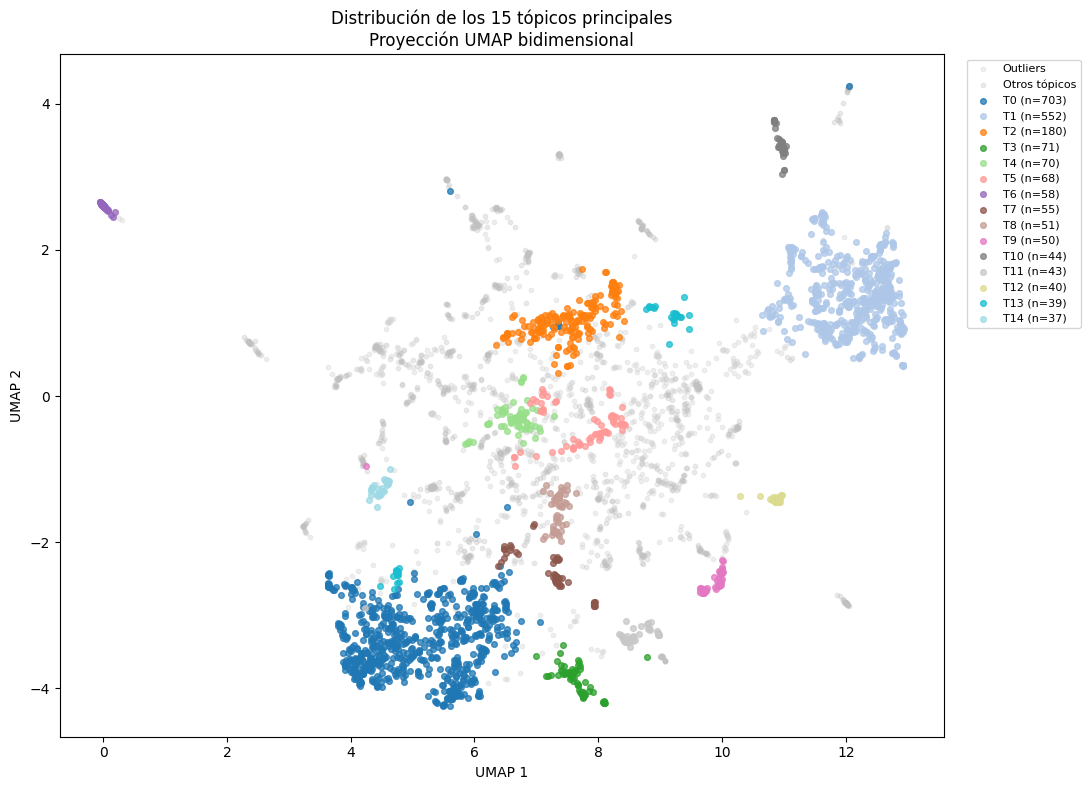

Outliers: 853 (21.83%)


In [ ]:
from umap import UMAP as UMAP_viz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

Path("content").mkdir(parents=True, exist_ok=True)

reductor_2d = UMAP_viz(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED,
    low_memory=True
)

embeddings_2d = reductor_2d.fit_transform(embeddings)

etiquetas_topico = np.asarray(
    df_fragmentos["topico_inicial"]
)

conteos_topicos = (
    pd.Series(etiquetas_topico)
    .loc[lambda s: s != -1]
    .value_counts()
)

topicos_principales = (
    conteos_topicos
    .head(15)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 8))

# Outliers
mascara_outlier = etiquetas_topico == -1

ax.scatter(
    embeddings_2d[mascara_outlier, 0],
    embeddings_2d[mascara_outlier, 1],
    c="lightgray",
    s=10,
    alpha=0.35,
    label="Outliers"
)

# Otros tópicos
mascara_otros = (
    (etiquetas_topico != -1) &
    (~np.isin(etiquetas_topico, topicos_principales))
)

ax.scatter(
    embeddings_2d[mascara_otros, 0],
    embeddings_2d[mascara_otros, 1],
    c="silver",
    s=10,
    alpha=0.30,
    label="Otros tópicos"
)

colores = plt.cm.tab20(
    np.linspace(0, 1, len(topicos_principales))
)

for color, topico in zip(
    colores,
    topicos_principales
):
    mascara = etiquetas_topico == topico

    ax.scatter(
        embeddings_2d[mascara, 0],
        embeddings_2d[mascara, 1],
        color=color,
        s=17,
        alpha=0.75,
        label=f"T{topico} (n={mascara.sum()})"
    )

ax.set_title(
    "Distribución de los 15 tópicos principales\n"
    "Proyección UMAP bidimensional"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "/content/dispersion_topicos_top15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Outliers: {mascara_outlier.sum()} "
    f"({100 * mascara_outlier.mean():.2f}%)"
)

## Fase 4 — Auditoría y depuración temática

Los tópicos generados por HDBSCAN se inspeccionan utilizando:

1. Palabras y expresiones representativas.
2. Número de fragmentos.
3. Número de estudios diferentes por tópico.
4. Porcentaje aportado por el estudio dominante.
5. Documentos representativos.
6. Presencia de bibliografía, licencias, metadatos o errores de OCR.

Los tópicos específicos de un solo estudio no se eliminan automáticamente. Se
clasifican como innovaciones específicas o temas emergentes, mientras que los
tópicos formados por referencias, metadatos y OCR se excluyen.

In [ ]:
import pandas as pd
import numpy as np

df_asignaciones = df_fragmentos.copy()

registros_auditoria = []

for topico, grupo in df_asignaciones.groupby(
    "topico_inicial"
):
    if topico == -1:
        continue

    distribucion_estudios = (
        grupo["id_estudio"]
        .value_counts()
    )

    palabras = [
        palabra
        for palabra, peso
        in modelo_topicos.get_topic(topico)[:10]
    ]

    registros_auditoria.append({
        "topico": topico,
        "fragmentos": len(grupo),
        "estudios": distribucion_estudios.size,
        "estudio_dominante":
            distribucion_estudios.index[0],
        "dominancia_pct": round(
            100 * distribucion_estudios.iloc[0] /
            len(grupo),
            2
        ),
        "palabras_clave": ", ".join(palabras)
    })

df_auditoria_topicos = pd.DataFrame(
    registros_auditoria
).sort_values("topico")

def clasificar_transversalidad(fila):

    if fila["estudios"] == 1:
        return "Específico de un estudio"

    if (
        fila["estudios"] < 3 or
        fila["dominancia_pct"] > 70
    ):
        return "Baja transversalidad"

    return "Transversal"

df_auditoria_topicos["clasificacion"] = (
    df_auditoria_topicos.apply(
        clasificar_transversalidad,
        axis=1
    )
)

display(df_auditoria_topicos)

df_auditoria_topicos.to_csv(
    "/content/auditoria_topicos.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# DOCUMENTOS REPRESENTATIVOS DE TÓPICOS SOSPECHOSOS
# ============================================================

TOPICOS_PARA_REVISAR = [
    0, 1, 6, 9, 18, 19, 23, 36, 54
]

topicos_existentes = set(
    df_auditoria_topicos["topico"]
)

for topico in TOPICOS_PARA_REVISAR:

    if topico not in topicos_existentes:
        continue

    print("\n" + "=" * 90)
    print(f"TÓPICO {topico}")

    palabras = modelo_topicos.get_topic(topico)

    print(
        "Palabras:",
        [
            palabra
            for palabra, peso
            in palabras[:10]
        ]
    )

    documentos = (
        modelo_topicos
        .get_representative_docs(topico)
    )

    for numero, documento in enumerate(
        documentos[:3],
        start=1
    ):
        print(
            f"\nDocumento representativo {numero}:\n"
            f"{documento[:700]}"
        )

,topico,fragmentos,estudios,estudio_dominante,dominancia_pct,palabras_clave,clasificacion
0,0,703,74,W64,2.84,"min, solution, ml, pbs, medium, added, µl, usa...",Transversal
1,1,552,72,P27,3.99,"wang, zhang, li, liu, chen, eng, yang, univers...",Transversal
2,2,180,41,P21,11.11,"alp, sf, cs sf, sralg, sf sralg, gelma cells, ...",Transversal
3,3,71,17,W14,12.68,"printing, ink, print, extrusion, printing proc...",Transversal
4,4,70,19,P05,25.71,"gqds, tri-layered, degradation, weight loss, s...",Transversal
5,5,68,17,P63,39.71,"keratin, kgh, kg, kgh scaffold, kg scaffold, a...",Transversal
6,6,58,7,W20,22.41,"ooff, aanndd, aa, ffiigguurree, fap, ss, hh, h...",Transversal
7,7,55,9,W18,34.55,"yarn, xg, heparin, hydrogel hydrogel, gels, hg...",Transversal
8,8,51,14,W05,29.41,"sponge, gelatine, fibres, pcl gelatine, humidi...",Transversal
9,9,50,3,W25,90.00,"mxene, mxene-ecm, micro-meshes, mxene-ecm scaf...",Baja transversalidad



TÓPICO 0
Palabras: ['min', 'solution', 'ml', 'pbs', 'medium', 'added', 'µl', 'usa', 'incubated', 'samples']

Documento representativo 1:
solution was added to the reaction system, followed by the addition of 12 mL of deionized water. After 5 min, the absorbance of the reaction solution containing the test substance was measured at 510 nm. The scavenging rate was calculated by Equation (3). 2.8. Cell compatibility PC-12 cells were seeded in 24-well plates at a density of 5 × 104 cells per well and cultured in complete medium consisting of RPMI 1640 (Gibco) supplemented with 5% fetal bovine serum (FBS), 10% heat-inactivated horse serum (Gibco), and 85% basal RPMI 1640 medium (Gibco). The cells were then incubated in a humidified atmosphere with 5% CO at 37 °C for 6 h, followed by co-culture with the scaffolds for 24 and 48 h re

Documento representativo 2:
The Statistical Product and Service Solutions (SPSS) software of 30 KV and 30 Ma. package, version 20.0 (IBM Corp., Armonk, NY, Unit

In [ ]:
# ============================================================
# TÓPICOS DE RUIDO CONFIRMADO
# ============================================================

# De acuerdo con la lista actual:
# 1  = referencias/autores/journals
# 6  = OCR corrupto
# 9  = contribuciones/licencia/financiación
# 18 = fragmentación OCR
# 23 = referencias bibliográficas

TOPICOS_RUIDO_SEGURO = [
    1, 6, 9, 18, 23
]

# Agrega aquí los tópicos que confirmes manualmente
# después de leer sus documentos representativos.
TOPICOS_RUIDO_ADICIONAL = [
    # 54,
]

TOPICOS_A_EXCLUIR = sorted(
    set(
        TOPICOS_RUIDO_SEGURO +
        TOPICOS_RUIDO_ADICIONAL
    )
)

df_fragmentos_ruido = df_fragmentos[
    df_fragmentos["topico_inicial"].isin(
        TOPICOS_A_EXCLUIR
    )
].copy()

df_fragmentos_limpio = df_fragmentos[
    (
        ~df_fragmentos["topico_inicial"]
        .isin(TOPICOS_A_EXCLUIR)
    ) &
    (
        df_fragmentos["topico_inicial"] != -1
    )
].copy()

print("Tópicos excluidos:", TOPICOS_A_EXCLUIR)

print(
    "Tópicos genuinos restantes:",
    df_fragmentos_limpio[
        "topico_inicial"
    ].nunique()
)

print(
    "Fragmentos temáticos restantes:",
    len(df_fragmentos_limpio)
)

print(
    "Fragmentos excluidos por ruido:",
    len(df_fragmentos_ruido)
)

df_fragmentos_limpio.to_csv(
    "/content/fragmentos_topicos_limpios.csv",
    index=False,
    encoding="utf-8-sig"
)

df_fragmentos_ruido.to_csv(
    "/content/fragmentos_ruido_excluido.csv",
    index=False,
    encoding="utf-8-sig"
)

Tópicos excluidos: [1, 6, 9, 18, 23]
Tópicos genuinos restantes: 53
Fragmentos temáticos restantes: 2331
Fragmentos excluidos por ruido: 724


## Fase 5 --- Clasificacion de topicos por 5 ejes de contenido (reemplaza K-means)

En vez de forzar cada topico dentro de una unica macrocategoria excluyente (K-means),
se clasifica cada topico simultaneamente en 5 ejes de contenido no excluyentes, usando
los pesos c-TF-IDF que BERTopic ya calculo para cada topico (no se recalculan aparte).

**Los 5 ejes:** Material/Composicion, Estrategia de Fabricacion/Modificacion, Propiedad
de Ingenieria, Funcion Biologica/Terapeutica, Aplicacion Tisular/Biomedica.

**Regla de exclusion por predominio metodologico**, aplicada sobre los pesos c-TF-IDF:

$$S_{met}(t) = \frac{\sum_{w \in Metodologia} cTFIDF(w,t)}{\sum_{w \in Metodologia \cup Contenido} cTFIDF(w,t)}$$

- $S_{met} \geq 0.70$ y vocabulario metodologico en $\geq$60% de fragmentos --- excluir automaticamente
- $S_{met} < 0.40$ --- conservar automaticamente
- $0.40 \leq S_{met} < 0.70$ --- revision manual

Un topico puede pertenecer a varios ejes a la vez (no es una particion excluyente como
K-means); esto refleja que un mismo estudio real suele hablar de material, fabricacion,
propiedad, funcion y aplicacion simultaneamente.

In [ ]:
import numpy as np
import pandas as pd
import re
from pathlib import Path

Path("content").mkdir(parents=True, exist_ok=True)

# ============================================================
# DICCIONARIOS: 5 EJES DE CONTENIDO + VOCABULARIO METODOLOGICO
# ============================================================

EJES = {
    "Material_Composicion": [
        "pcl","pla","plga","chitosan","cs","gelma","collagen","hydroxyapatite","ha","hap","nhap",
        "bioglass","bbg","graphene","gph","mxene","zno","agnps","ag","curcumin","cur",
        "gelatin","gelatine","alginate","pva","pu","polyurethane","mof","tio2","pvdf",
        "keratin","elastin","fibroin","agarose","tcp","bioceramic"
    ],
    "Estrategia_Fabricacion": [
        "printing","3d","bioprinting","dlp","photopolymerization","electrospinning",
        "freeze","freezing","lyophilization","foaming","crosslinking","crosslinked",
        "coating","aminolysis","polydopamine","pda","plasma","ald","peald","sintering",
        "nanoparticle","nps","nano","gyroid","tpms","core","shell","gradient","extrusion","ink"
    ],
    "Propiedad_Ingenieria": [
        "mechanical","modulus","compressive","tensile","strength","stiffness","porosity",
        "pore","degradation","swelling","viscosity","rheology","printability","stability",
        "crystallinity","hydrophilic","conductivity","piezoelectric","radiopaque",
        "elastic","elongation","hardness","morphology","diameter"
    ],
    "Funcion_Biologica": [
        "cytocompatibility","adhesion","proliferation","migration","differentiation",
        "osteogenic","osteogenesis","angiogenic","angiogenesis","antibacterial","bacterial",
        "antifungal","immunomodulation","healing","wound","release","controlled","antioxidant",
        "recruitment","stimulation","integration","viability","alp","calcium","mc3t3",
        "vegf","inhibition","aureus","cytotoxicity","mineralization"
    ],
    "Aplicacion_Tisular": [
        "bone","craniofacial","dental","tooth","cartilage","osteochondral","skin","wound",
        "nerve","neural","neuron","vascular","vessel","endothelial","tendon","ligament",
        "meniscus","bladder","urological","muscle","dermal","skeletal","defect"
    ],
}
VOCAB_CONTENIDO = sorted(set(w for lista in EJES.values() for w in lista))

VOCAB_METODOLOGIA = [
    "sem","tem","ftir","raman","xrd","xps","dsc","tga","contact","angle",
    "mtt","live","dead","qpcr","western","cfu","mic","histology","anova",
    "incubated","incubation","medium","pbs","min","ml","solution","water","well",
    "culture","cultured","rpm","centrifuged","statistical","significant","test",
    "peak","peaks","spectra","assay","staining","stained","dye","washing","significance",
    # agregado tras validacion cruzada con la auditoria manual (Topico 9: CRediT/funding)
    "writing","funding","statement","contribution","conceptualization","supervision",
    "methodology","validation","editing","review","resources","project"
]

# patrones de ruido bibliografico / OCR (heuristica sobre palabras clave top)
PATRON_OCR = re.compile(r'(.)\1.*(.)\2')
AUTORES_COMUNES = {"wang","zhang","li","liu","chen","wu","xu","et","al","mater","sci","doi","org","https","journal","adv"}

# ============================================================
# CALCULO DE S_met USANDO LOS PESOS c-TF-IDF QUE BERTOPIC YA CALCULO
# ============================================================

ids_topicos_presentes = sorted(
    t for t in df_fragmentos_limpio["topico_inicial"].unique() if t != -1
)

registros_clasificacion = []
for tid in ids_topicos_presentes:
    palabras_pesos = modelo_topicos.get_topic(tid)  # [(palabra, peso_ctfidf), ...]
    palabras_pesos = [(p.lower(), w) for p, w in palabras_pesos]

    peso_met = sum(w for p, w in palabras_pesos if p in VOCAB_METODOLOGIA)
    peso_cont = sum(w for p, w in palabras_pesos if p in VOCAB_CONTENIDO)
    denominador = peso_met + peso_cont
    s_met = peso_met / denominador if denominador > 0 else 0.0

    top_palabras = [p for p, w in palabras_pesos[:10]]

    # cobertura: % de fragmentos del topico que contienen >=1 termino metodologico
    frags = df_fragmentos_limpio.loc[
        df_fragmentos_limpio["topico_inicial"] == tid, "texto"
    ].tolist()
    n_con_metodologia = sum(
        1 for f in frags if any(m in str(f).lower() for m in VOCAB_METODOLOGIA)
    )
    cobertura_metodologia = n_con_metodologia / len(frags) if frags else 0

    # deteccion de ruido bibliografico/editorial y OCR
    n_autores = sum(1 for p in top_palabras[:10] if p in AUTORES_COMUNES)
    es_bibliografico = n_autores >= 3
    es_ocr = sum(1 for p in top_palabras[:10] if PATRON_OCR.search(p)) >= 2

    # ejes de contenido detectados (multi-etiqueta, no excluyente)
    ejes_detectados = {
        eje: [p for p, w in palabras_pesos if p in diccionario]
        for eje, diccionario in EJES.items()
        if any(p in diccionario for p, w in palabras_pesos)
    }

    if es_ocr:
        categoria, decision = "ruido_ocr", "excluir"
    elif es_bibliografico:
        categoria, decision = "bibliografico_editorial", "excluir"
    elif s_met >= 0.70 and cobertura_metodologia >= 0.60:
        categoria, decision = "metodologico_dominante", "excluir"
    elif s_met < 0.40:
        categoria, decision = "contenido_tematico", "conservar"
    else:
        categoria, decision = "mixto_metodologico_tematico", "revisar manualmente"

    registros_clasificacion.append({
        "topico": int(tid),
        "n_fragmentos": len(frags),
        "s_met": round(float(s_met), 3),
        "cobertura_metodologia_pct": round(float(cobertura_metodologia) * 100, 1),
        "top_palabras": ", ".join(top_palabras),
        "categoria": categoria,
        "decision": decision,
        "Material_Composicion": "Material_Composicion" in ejes_detectados,
        "Estrategia_Fabricacion": "Estrategia_Fabricacion" in ejes_detectados,
        "Propiedad_Ingenieria": "Propiedad_Ingenieria" in ejes_detectados,
        "Funcion_Biologica": "Funcion_Biologica" in ejes_detectados,
        "Aplicacion_Tisular": "Aplicacion_Tisular" in ejes_detectados,
    })

df_clasificacion_ejes = pd.DataFrame(registros_clasificacion).sort_values("topico")
display(df_clasificacion_ejes)

print("\n=== Distribucion por categoria ===")
print(df_clasificacion_ejes["categoria"].value_counts())
print("\n=== Distribucion por decision ===")
print(df_clasificacion_ejes["decision"].value_counts())

df_clasificacion_ejes.to_csv(
    "/content/clasificacion_5ejes_topicos.csv", index=False, encoding="utf-8-sig"
)


,topico,n_fragmentos,s_met,cobertura_metodologia_pct,top_palabras,categoria,decision,Material_Composicion,Estrategia_Fabricacion,Propiedad_Ingenieria,Funcion_Biologica,Aplicacion_Tisular
0,0,703,1.000,99.7,"min, solution, ml, pbs, medium, added, µl, usa...",metodologico_dominante,excluir,False,False,False,False,False
1,2,180,0.463,99.4,"alp, sf, cs sf, sralg, sf sralg, gelma cells, ...",mixto_metodologico_tematico,revisar manualmente,False,False,False,True,False
2,3,71,0.000,97.2,"printing, ink, print, extrusion, printing proc...",contenido_tematico,conservar,False,True,True,False,False
3,4,70,0.000,94.3,"gqds, tri-layered, degradation, weight loss, s...",contenido_tematico,conservar,False,False,True,False,False
4,5,68,0.000,100.0,"keratin, kgh, kg, kgh scaffold, kg scaffold, a...",contenido_tematico,conservar,True,False,False,False,False
5,7,55,0.000,96.4,"yarn, xg, heparin, hydrogel hydrogel, gels, hg...",contenido_tematico,conservar,False,False,False,False,False
6,8,51,0.000,98.0,"sponge, gelatine, fibres, pcl gelatine, humidi...",contenido_tematico,conservar,True,False,False,False,False
7,10,44,1.000,88.6,"manuscript, statement, funding, writing, contr...",metodologico_dominante,excluir,False,False,False,False,False
8,11,43,0.000,97.7,"nch, carbomer, nhap, gelma, gelma nhap, ca2, g...",contenido_tematico,conservar,True,False,False,False,False
9,12,40,0.000,95.0,"tendon, tenocytes, tendons, static, cell scaff...",ruido_ocr,excluir,True,False,False,False,True



=== Distribucion por categoria ===
categoria
contenido_tematico             48
metodologico_dominante          2
ruido_ocr                       2
mixto_metodologico_tematico     1
Name: count, dtype: int64

=== Distribucion por decision ===
decision
conservar              48
excluir                 4
revisar manualmente     1
Name: count, dtype: int64


In [ ]:
# ============================================================
# APLICAR LA DECISION: excluir topicos metodologicos/ruido,
# marcar los "revisar manualmente" para tu inspeccion, y propagar
# los 5 ejes a nivel de fragmento (multi-etiqueta)
# ============================================================

topicos_excluir_auto = set(
    df_clasificacion_ejes.loc[
        df_clasificacion_ejes["decision"] == "excluir", "topico"
    ]
)
topicos_revisar = set(
    df_clasificacion_ejes.loc[
        df_clasificacion_ejes["decision"] == "revisar manualmente", "topico"
    ]
)

print("Topicos excluidos automaticamente:", sorted(topicos_excluir_auto))
print("Topicos que requieren tu revision manual:", sorted(topicos_revisar))
print("(Revisalos con modelo_topicos.get_representative_docs(topico) antes de decidir)")

# ===== EDITA esta lista despues de revisar los topicos marcados arriba =====
TOPICOS_REVISADOS_EXCLUIR = [
    # agrega aqui los IDs de topicos_revisar que confirmes como ruido/metodologicos
]

TOPICOS_A_EXCLUIR_FINAL = sorted(topicos_excluir_auto | set(TOPICOS_REVISADOS_EXCLUIR))

df_fragmentos_ejes = df_fragmentos_limpio[
    ~df_fragmentos_limpio["topico_inicial"].isin(TOPICOS_A_EXCLUIR_FINAL)
].copy()

# mapa topico -> ejes (multi-etiqueta), para propagar a nivel de fragmento
mapa_topico_ejes = df_clasificacion_ejes.set_index("topico")[
    ["Material_Composicion","Estrategia_Fabricacion","Propiedad_Ingenieria",
     "Funcion_Biologica","Aplicacion_Tisular"]
].to_dict(orient="index")

for eje in ["Material_Composicion","Estrategia_Fabricacion","Propiedad_Ingenieria",
            "Funcion_Biologica","Aplicacion_Tisular"]:
    df_fragmentos_ejes[eje] = df_fragmentos_ejes["topico_inicial"].map(
        lambda t: mapa_topico_ejes.get(t, {}).get(eje, False)
    )

print(f"\nFragmentos finales tras excluir ruido/metodologia: {len(df_fragmentos_ejes)}")
print(f"Topicos finales: {df_fragmentos_ejes['topico_inicial'].nunique()}")

df_fragmentos_ejes.to_csv(
    "/content/fragmentos_con_5ejes.csv", index=False, encoding="utf-8-sig"
)


Topicos excluidos automaticamente: [0, 10, 12, 40]
Topicos que requieren tu revision manual: [2]
(Revisalos con modelo_topicos.get_representative_docs(topico) antes de decidir)

Fragmentos finales tras excluir ruido/metodologia: 1524
Topicos finales: 49


In [ ]:
# ===== Fase 5.5 -- Normalizacion DEFINITIVA (version completa, basada en auditoria total) =====
import re

PATRONES_NORMALIZACION = [
    # --- Hidroxiapatita: 665 menciones reales repartidas en 13 formas distintas ---
    (r'\bnano-?hydroxyapatite\w*\b', 'hydroxyapatite'),
    (r'\bsoluhydroxyapatite\b', 'hydroxyapatite'),
    (r'\bhydroxyapatites?\b', 'hydroxyapatite'),
    (r'\bn-?hap\w*\b', 'hydroxyapatite'),      # nhap, n-hap, nhas
    (r'\bn-?ha\b', 'hydroxyapatite'),           # n-ha, nha
    (r'\bhap0\b', 'hydroxyapatite'),
    (r'\bhap-?based\b', 'hydroxyapatite'),
    (r'\bhap-?enriched\b', 'hydroxyapatite'),
    (r'\bhap-?containing\b', 'hydroxyapatite'),
    (r'\bhap\b', 'hydroxyapatite'),             # HAp solo (232 veces, la mas frecuente)
    (r'\bHA\b', 'hydroxyapatite'),              # HA solo, mayuscula exacta

    # --- Quitosano: chitosan domina, cts es variante real, chitin NO se fusiona (es otra sustancia) ---
    (r'\bcts\b', 'chitosan'),
    (r'\bCS\b', 'chitosan'),

    # --- PCL: variantes de concentracion se unifican al material base ---
    (r'\bpcl\d+\b', 'pcl'),      # pcl25, pcl50, pcl35, pcl1, pcl2, pcl3
    (r'\bpcls\b', 'pcl'),
]

def normalizar_texto(texto):
    texto_normalizado = texto
    for patron, reemplazo in PATRONES_NORMALIZACION:
        es_case_sensitive = patron in (r'\bHA\b', r'\bCS\b')
        if es_case_sensitive:
            texto_normalizado = re.sub(patron, reemplazo, texto_normalizado)
        else:
            texto_normalizado = re.sub(patron, reemplazo, texto_normalizado, flags=re.IGNORECASE)
    return texto_normalizado

df_fragmentos_ejes["texto_normalizado"] = df_fragmentos_ejes["texto"].apply(normalizar_texto)

n_cambiados = (df_fragmentos_ejes["texto_normalizado"] != df_fragmentos_ejes["texto"]).sum()
print(f"Fragmentos donde se normalizo al menos un termino: {n_cambiados} de {len(df_fragmentos_ejes)}")

Fragmentos donde se normalizo al menos un termino: 592 de 1524


## Fase 6 --- Extraccion de entidades biomedicas (NER)

Independiente del analisis de topicos: se extraen entidades biomedicas (materiales, tipos
celulares, estructuras biologicas) de cada fragmento usando un modelo de NER biomedico
via HuggingFace Transformers (`d4data/biomedical-ner-all`). Se eligio esta ruta en vez de
scispaCy porque scispaCy tiene conflictos de dependencias conocidos con versiones recientes
de spaCy (ver https://github.com/allenai/scispacy/issues), lo que lo hace menos confiable
para correr sin ajustes en un Colab nuevo.

In [ ]:
import torch
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForTokenClassification
)
from tqdm.auto import tqdm

tqdm.pandas()

dispositivo = (
    0 if torch.cuda.is_available() else -1
)

print(
    "Usando GPU"
    if dispositivo == 0
    else "Usando CPU"
)

NOMBRE_MODELO_NER = (
    "d4data/biomedical-ner-all"
)

tokenizer_ner = AutoTokenizer.from_pretrained(
    NOMBRE_MODELO_NER
)

modelo_ner = (
    AutoModelForTokenClassification
    .from_pretrained(NOMBRE_MODELO_NER)
)

extractor_ner = pipeline(
    "ner",
    model=modelo_ner,
    tokenizer=tokenizer_ner,
    aggregation_strategy="max",
    device=dispositivo
)

MAX_TOKENS_NER = min(
    512,
    tokenizer_ner.model_max_length
)

TOKENS_ESPECIALES_NER = (
    tokenizer_ner.num_special_tokens_to_add(
        pair=False
    )
)

TOKENS_CONTENIDO_NER = (
    MAX_TOKENS_NER -
    TOKENS_ESPECIALES_NER
)

SOLAPAMIENTO_NER = 50

def dividir_para_ner(texto):

    ids = tokenizer_ner.encode(
        texto,
        add_special_tokens=False,
        truncation=False
    )

    paso = (
        TOKENS_CONTENIDO_NER -
        SOLAPAMIENTO_NER
    )

    segmentos = []

    for inicio in range(0, len(ids), paso):

        ventana = ids[
            inicio:
            inicio + TOKENS_CONTENIDO_NER
        ]

        if not ventana:
            break

        segmento = tokenizer_ner.decode(
            ventana,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )

        segmentos.append(segmento)

        if (
            inicio +
            TOKENS_CONTENIDO_NER
            >= len(ids)
        ):
            break

    return segmentos


def normalizar_entidad(entidad):

    entidad = entidad.strip().lower()

    entidad = entidad.replace("##", "")
    entidad = entidad.replace("▁", "")

    entidad = " ".join(
        entidad.split()
    )

    return entidad


def entidad_valida(entidad):

    if not entidad:
        return False

    if len(entidad) <= 2:
        return False

    if entidad.isnumeric():
        return False

    return True


def extraer_entidades(texto):

    entidades = []

    try:
        segmentos = dividir_para_ner(texto)

        for segmento in segmentos:

            resultados = extractor_ner(
                segmento
            )

            for resultado in resultados:

                if resultado.get(
                    "score",
                    0
                ) < 0.50:
                    continue

                entidad = normalizar_entidad(
                    resultado["word"]
                )

                if entidad_valida(entidad):
                    entidades.append(entidad)

        return list(dict.fromkeys(entidades))

    except Exception as error:
        return []


print(
    f"Procesando "
    f"{len(df_fragmentos_ejes)} "
    f"fragmentos con NER..."
)

df_fragmentos_ejes[
    "entidades"
] = (
    df_fragmentos_ejes[
        "texto_normalizado"
    ].progress_apply(extraer_entidades)
)

todas_las_entidades = [
    entidad
    for lista in df_fragmentos_ejes[
        "entidades"
    ]
    for entidad in lista
]

print(
    "Entidades extraídas:",
    len(todas_las_entidades)
)

print(
    "Entidades únicas:",
    len(set(todas_las_entidades))
)

display(
    df_fragmentos_ejes[
        [
            "id_fragmento",
            "topico_inicial",
            "Material_Composicion",
            "Estrategia_Fabricacion",
            "Propiedad_Ingenieria",
            "Funcion_Biologica",
            "Aplicacion_Tisular",
            "entidades"
        ]
    ].head()
)

df_fragmentos_ejes.to_csv(
    "/content/fragmentos_con_entidades.csv",
    index=False,
    encoding="utf-8-sig"
)

Usando CPU


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Procesando 1524 fragmentos con NER...


  0%|          | 0/1524 [00:00<?, ?it/s]

Entidades extraídas: 24470
Entidades únicas: 10550


,id_fragmento,topico_inicial,Material_Composicion,Estrategia_Fabricacion,Propiedad_Ingenieria,Funcion_Biologica,Aplicacion_Tisular,entidades
0,3D-Architected_Natural_Tooth-Derived_Scaffolds...,20,False,True,False,False,True,"[architected, natural tooth - derived, reinfor..."
1,3D-Architected_Natural_Tooth-Derived_Scaffolds...,16,True,True,False,False,True,"[mechanical tests, multiphysics, compatibility..."
4,3D-Architected_Natural_Tooth-Derived_Scaffolds...,20,False,True,False,False,True,"[some - tooth - derived materials, bone, high,..."
6,3D-Architected_Natural_Tooth-Derived_Scaffolds...,16,True,True,False,False,True,"[tissue - engineered scaffolds, interfacial en..."
7,3D-Architected_Natural_Tooth-Derived_Scaffolds...,16,True,True,False,False,True,"[1650 cm, 1543 cm, collagen, structure, - temp..."


## Fase 7 — Construcción de redes de co-ocurrencia por grupo temático

Para cada uno de los K grupos temáticos, se construye una red donde los nodos son entidades
y las aristas conectan entidades que co-ocurren en el mismo fragmento, ponderadas por
frecuencia de co-ocurrencia.

In [ ]:
import networkx as nx
from itertools import combinations
from collections import Counter

EJES_CONTENIDO = [
    "Material_Composicion", "Estrategia_Fabricacion", "Propiedad_Ingenieria",
    "Funcion_Biologica", "Aplicacion_Tisular",
]

def construir_red_de_eje(df, nombre_eje):
    # un fragmento puede pertenecer a varios ejes a la vez (no excluyente),
    # asi que cada eje se filtra de forma independiente, no como particion
    subconjunto = df[df[nombre_eje] == True]
    contador_pares = Counter()
    for lista_entidades in subconjunto["entidades"]:
        entidades_unicas = list(set(lista_entidades))
        for par in combinations(sorted(entidades_unicas), 2):
            contador_pares[par] += 1

    G = nx.Graph()
    for (nodo_a, nodo_b), peso in contador_pares.items():
        if peso >= 2:  # umbral minimo de co-ocurrencia para incluir la arista
            G.add_edge(nodo_a, nodo_b, weight=peso)
    return G

redes_por_eje = {}
for nombre_eje in EJES_CONTENIDO:
    G = construir_red_de_eje(df_fragmentos_ejes, nombre_eje)
    redes_por_eje[nombre_eje] = G
    print(f"{nombre_eje}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")


Material_Composicion: 781 nodos, 5557 aristas
Estrategia_Fabricacion: 504 nodos, 3091 aristas
Propiedad_Ingenieria: 451 nodos, 3120 aristas
Funcion_Biologica: 538 nodos, 2644 aristas
Aplicacion_Tisular: 236 nodos, 629 aristas


## Fase 8 — Métricas de centralidad (grado y intermediación)

In [ ]:
resumen_centralidad = {}
for nombre_eje, G in redes_por_eje.items():
    if G.number_of_nodes() == 0:
        continue
    centralidad_grado = nx.degree_centrality(G)
    centralidad_intermediacion = nx.betweenness_centrality(G, weight='weight')

    top_grado = sorted(centralidad_grado.items(), key=lambda x: -x[1])[:5]
    top_intermediacion = sorted(centralidad_intermediacion.items(), key=lambda x: -x[1])[:5]

    resumen_centralidad[nombre_eje] = {
        "top_grado": top_grado,
        "top_intermediacion": top_intermediacion
    }
    print(f"\n=== Eje: {nombre_eje} ===")
    print("Top 5 por centralidad de grado (nodos mas conectados):", top_grado)
    print("Top 5 por intermediacion (posibles 'conceptos puente'):", top_intermediacion)



=== Eje: Material_Composicion ===
Top 5 por centralidad de grado (nodos mas conectados): [('hydroxyapatite', 0.40384615384615385), ('pcl', 0.3423076923076923), ('higher', 0.2153846153846154), ('chitosan', 0.17435897435897435), ('high', 0.16923076923076924)]
Top 5 por intermediacion (posibles 'conceptos puente'): [('hydroxyapatite', 0.19090573713333908), ('pcl', 0.17600426178694117), ('chitosan', 0.09088404021112818), ('higher', 0.09012675351803827), ('high', 0.08803514409508625)]

=== Eje: Estrategia_Fabricacion ===
Top 5 por centralidad de grado (nodos mas conectados): [('pcl', 0.3121272365805169), ('hydroxyapatite', 0.22664015904572563), ('gel', 0.2246520874751491), ('high', 0.18489065606361826), ('pda', 0.1769383697813121)]
Top 5 por intermediacion (posibles 'conceptos puente'): [('pcl', 0.16653608698902578), ('high', 0.12326267582409745), ('gel', 0.10491053062754414), ('hydroxyapatite', 0.10291183142323063), ('bone', 0.06523629524534925)]

=== Eje: Propiedad_Ingenieria ===
Top 5 p

## Fase 9 — Visualización de las redes

Genera una figura por grupo temático, con el mismo estilo usado en las Figuras 2 y 3 del paper
(tamaño de nodo = centralidad de grado, intensidad de color = centralidad de intermediación,
grosor de arista = frecuencia de co-ocurrencia).

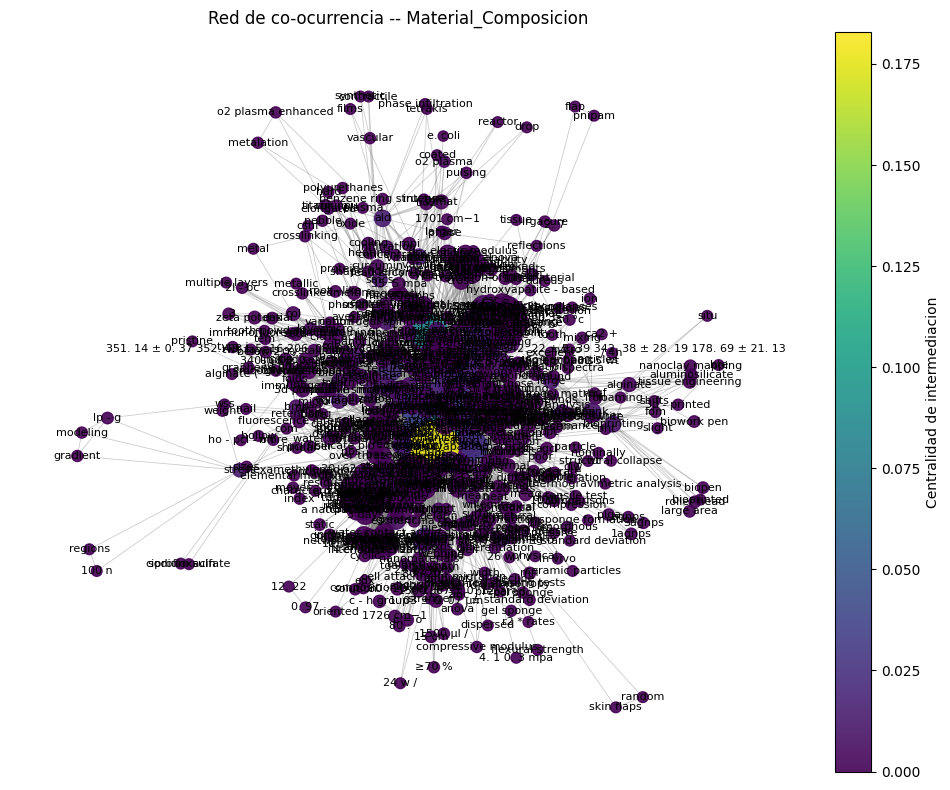

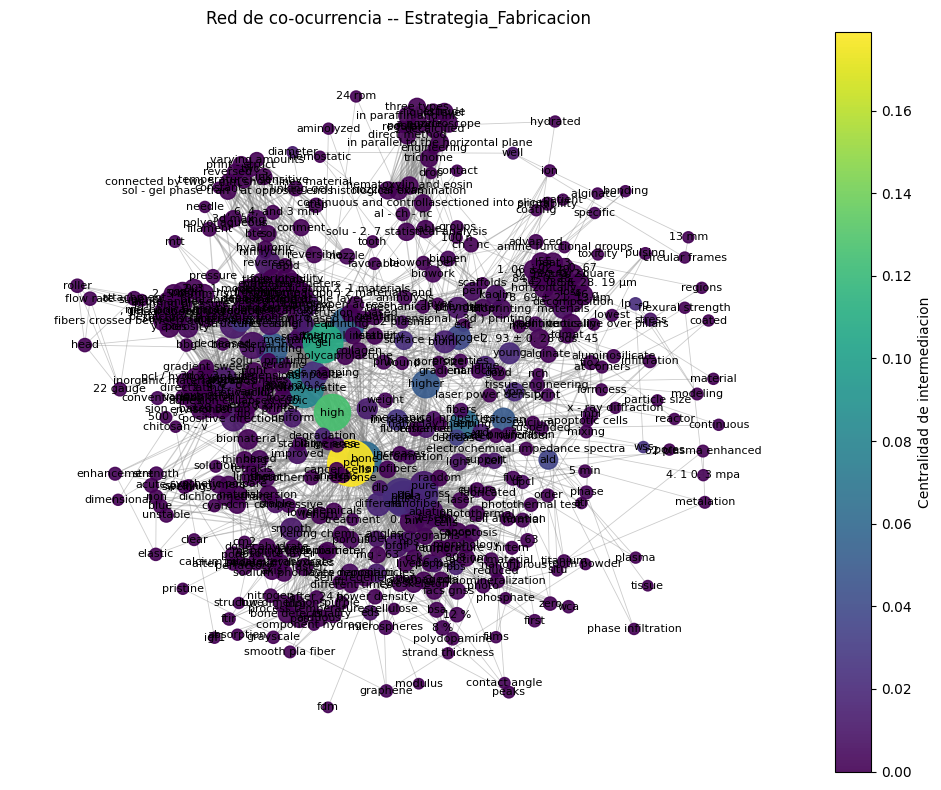

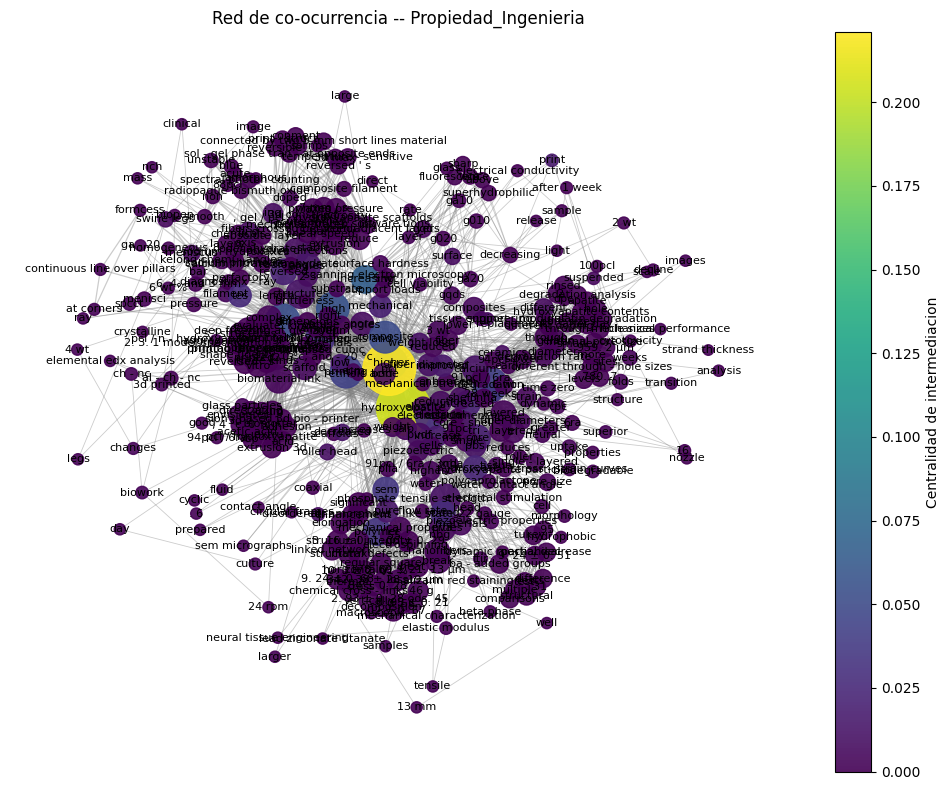

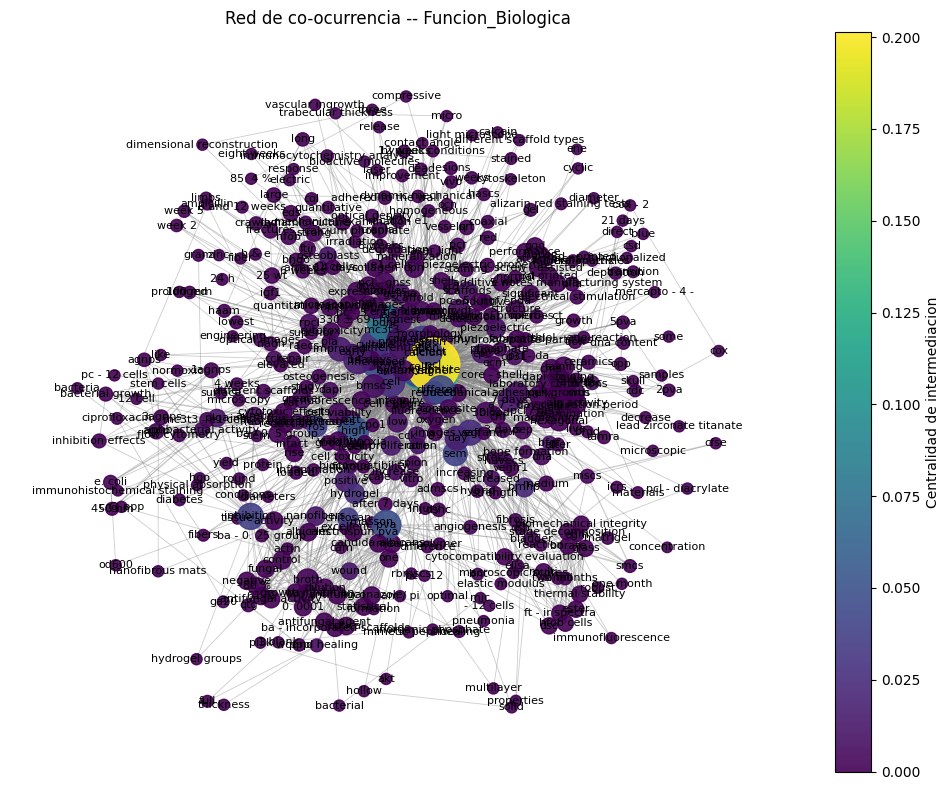

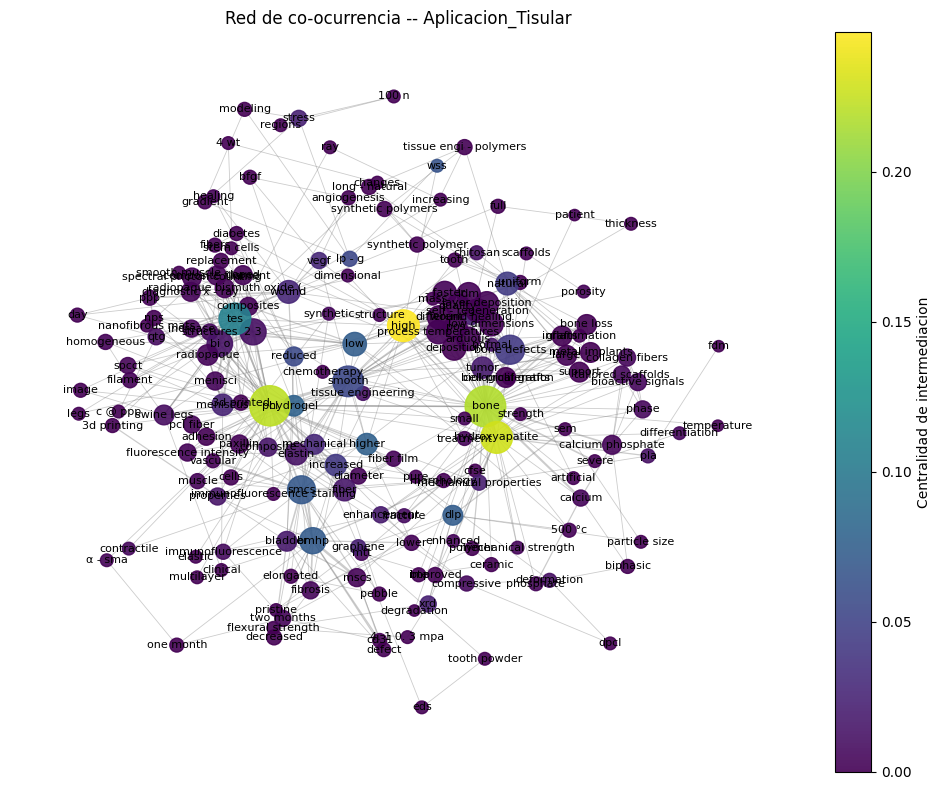

In [ ]:
def graficar_red(G, titulo, archivo_salida, grado_minimo=2):
    nodos_a_mostrar = [n for n, d in G.degree() if d >= grado_minimo]
    subG = G.subgraph(nodos_a_mostrar)

    if subG.number_of_nodes() == 0:
        print(f"Sin nodos suficientes para graficar '{titulo}' con grado_minimo={grado_minimo}")
        return

    pos = nx.spring_layout(subG, seed=SEED, k=0.5)
    centralidad_grado = nx.degree_centrality(subG)
    centralidad_intermediacion = nx.betweenness_centrality(subG, weight='weight')

    tamanos = [3000 * centralidad_grado[n] + 50 for n in subG.nodes()]
    colores = [centralidad_intermediacion[n] for n in subG.nodes()]
    anchos = [subG[u][v]['weight'] * 0.3 for u, v in subG.edges()]

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(subG, pos, width=anchos, alpha=0.4, edge_color='gray')
    nodos = nx.draw_networkx_nodes(subG, pos, node_size=tamanos, node_color=colores, cmap='viridis', alpha=0.9)
    nx.draw_networkx_labels(subG, pos, font_size=8)
    plt.colorbar(nodos, label='Centralidad de intermediacion')
    plt.title(titulo)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(archivo_salida, dpi=300)
    plt.show()

for nombre_eje, G in redes_por_eje.items():
    graficar_red(G, f"Red de co-ocurrencia -- {nombre_eje}",
                 f"/content/red_{nombre_eje}.pdf")


## Fase 9.5 --- Exportar redes para Gephi

Exporta cada red de co-ocurrencia en formato `.gexf` (formato nativo de Gephi) y descarga
los archivos automaticamente. Abre cada `.gexf` directamente en Gephi para explorar la red
de forma interactiva (zoom, filtros, distintos algoritmos de layout, etc.).

In [ ]:
from google.colab import files

In [ ]:
import networkx as nx
#from google.colab import files

for nombre_eje, G in redes_por_eje.items():
    if G.number_of_nodes() == 0:
        continue
    nombre_archivo = f"/content/red_{nombre_eje}.gexf"
    nx.write_gexf(G, nombre_archivo)
    print(f"Exportado: {nombre_archivo} ({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)")

print("\nIniciando descargas (revisa la carpeta de Descargas de tu navegador)...")
for nombre_eje, G in redes_por_eje.items():
    if G.number_of_nodes() == 0:
        continue
    files.download(f"/content/red_{nombre_eje}.gexf")


Exportado: /content/red_Material_Composicion.gexf (781 nodos, 5557 aristas)
Exportado: /content/red_Estrategia_Fabricacion.gexf (504 nodos, 3091 aristas)
Exportado: /content/red_Propiedad_Ingenieria.gexf (451 nodos, 3120 aristas)
Exportado: /content/red_Funcion_Biologica.gexf (538 nodos, 2644 aristas)
Exportado: /content/red_Aplicacion_Tisular.gexf (236 nodos, 629 aristas)

Iniciando descargas (revisa la carpeta de Descargas de tu navegador)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Fin del pipeline

Archivos generados en `/content/`:
- `embeddings_fragmentos.npy` — embeddings de todos los fragmentos
- `codo_silueta.png` — gráfico de selección de K
- `red_grupo_N.pdf` — una figura de red por cada grupo temático

**Siguiente paso manual:** nombra cada grupo temático (0, 1, 2...) según las palabras clave
de sus tópicos y el contenido de sus entidades más centrales (ej. "materials characterization",
"bone regeneration", etc.), tal como en la Sección 4.2 del paper.